In [5]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

log_path = Path('log_5197318')  # 如文件名不同，这里改成对应名字
text = log_path.read_text(encoding='utf-8')
lines = text.splitlines()

records = []
i = 0
while i < len(lines):
    line = lines[i]
    # 例如：Epoch 40, Train Loss: 0.0595, Val Loss: 0.0574
    m = re.match(r"Epoch\s+(\d+),\s*Train Loss:\s*([0-9.eE+-]+),\s*Val Loss:\s*([0-9.eE+-]+)", line)
    if m:
        epoch = int(m.group(1))
        train_loss = float(m.group(2))
        val_loss = float(m.group(3))

        # 往下找这一段里的 RMSE 行
        tr_e_rmse = tr_f_rmse = va_e_rmse = va_f_rmse = None
        j = i + 1
        while j < len(lines) and not lines[j].startswith("Epoch "):
            if "train_e/atom_rmse:" in lines[j]:
                tr_e_rmse = float(lines[j].split(":")[-1].strip())
            elif "train_f_rmse:" in lines[j]:
                tr_f_rmse = float(lines[j].split(":")[-1].strip())
            elif "val_e/atom_rmse:" in lines[j]:
                va_e_rmse = float(lines[j].split(":")[-1].strip())
            elif "val_f_rmse:" in lines[j]:
                va_f_rmse = float(lines[j].split(":")[-1].strip())
            j += 1

        if all(v is not None for v in [tr_e_rmse, tr_f_rmse, va_e_rmse, va_f_rmse]):
            records.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_e_rmse": tr_e_rmse,
                "val_e_rmse": va_e_rmse,
                "train_f_rmse": tr_f_rmse,
                "val_f_rmse": va_f_rmse,
            })

        i = j
    else:
        i += 1

df = pd.DataFrame(records).sort_values("epoch").reset_index(drop=True)
df.tail()


,epoch,train_loss,val_loss,train_e_rmse,val_e_rmse,train_f_rmse,val_f_rmse
33,70,0.0398,0.0400,0.000173,0.000214,0.006304,0.006319
34,80,0.0410,0.0410,0.000484,0.000283,0.006414,0.006407
35,80,0.0398,0.0400,0.000174,0.000176,0.006304,0.006321
36,90,0.0405,0.0407,0.000347,0.000182,0.006368,0.006379
37,100,0.0404,0.0406,0.000353,0.000471,0.006362,0.006372


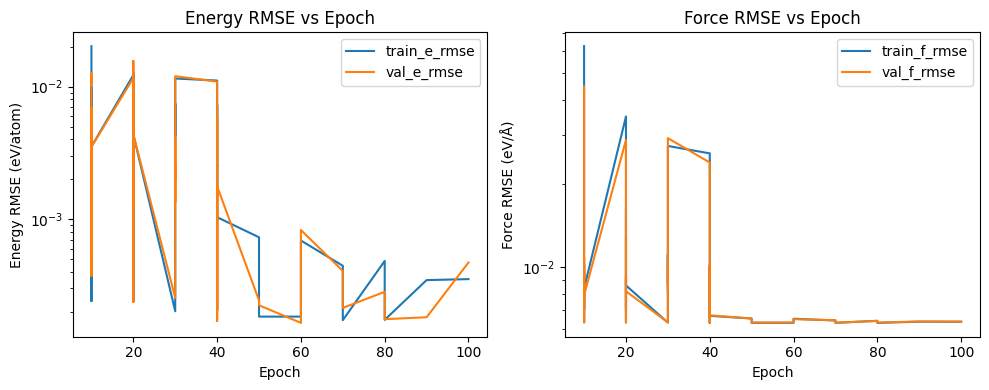

In [6]:
# 能量 RMSE 曲线（train / val）
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(df['epoch'], df['train_e_rmse'], label='train_e_rmse')
axes[0].plot(df['epoch'], df['val_e_rmse'], label='val_e_rmse')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Energy RMSE (eV/atom)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('Energy RMSE vs Epoch')

# 力 RMSE 曲线（train / val）
axes[1].plot(df['epoch'], df['train_f_rmse'], label='train_f_rmse')
axes[1].plot(df['epoch'], df['val_f_rmse'], label='val_f_rmse')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Force RMSE (eV/Å)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Force RMSE vs Epoch')

plt.tight_layout()
plt.show()


In [7]:
# 最后一个阶段（最大的 epoch 段）上的最佳指标
print('min val_e_rmse:', df['val_e_rmse'].min())
print('min val_f_rmse:', df['val_f_rmse'].min())
df.loc[df['val_f_rmse'].idxmin()]


min val_e_rmse: 0.000165
min val_f_rmse: 0.006319


epoch           70.000000
train_loss       0.039800
val_loss         0.040000
train_e_rmse     0.000173
val_e_rmse       0.000214
train_f_rmse     0.006304
val_f_rmse       0.006319
Name: 33, dtype: float64

In [ ]:
import os, sys
from pathlib import Path

import numpy as np
import torch

import cace
from cace.tools import Metrics
from cace.tools import torch_geometric
from cace.data.extxyz_charge import get_dataset_from_extxyz_with_charge
from cace.representations import Cace
from cace.modules import BesselRBF, PolynomialCutoff
from cace.modules import ChargeEq
from cace.tools.scatter import scatter_sum
from cace.models.atomistic import NeuralNetworkPotential

# 这一格在 NaCl 目录下，统一构建“带 Forces 的训练同构模型”，
# 并用 Metrics 重新计算 train/valid 的 e/atom 与 f 的 MAE/RMSE，方便和 log 对表。

HERE = Path(os.getcwd()).resolve()
if HERE.name == "fit-4hdnnp-NaCl":
    ROOT_DIR = HERE.parent
    DATA_DIR = HERE
else:
    ROOT_DIR = HERE
    DATA_DIR = ROOT_DIR / "fit-4hdnnp-NaCl"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)
print("device:", device)

cutoff = 5.29
Fourier_node = 18

radial_basis = BesselRBF(cutoff=cutoff, n_rbf=6, trainable=True)
cutoff_fn = PolynomialCutoff(cutoff=cutoff)

rep = Cace(
    zs=[11, 17],
    n_atom_basis=2,
    embed_receiver_nodes=True,
    cutoff=cutoff,
    cutoff_fn=cutoff_fn,
    radial_basis=radial_basis,
    n_radial_basis=8,
    max_l=3,
    max_nu=3,
    num_message_passing=0,
    type_message_passing=["Bchi"],
    args_message_passing={"Bchi": {"shared_channels": False, "shared_l": False}},
    device=device,
    timeit=False,
    forward_features=["atomic_numbers"],
).to(device)

sr_energy = cace.modules.atomwise.Atomwise(
    n_layers=3,
    output_key="SR_energy",
    n_hidden=[32, 16],
    use_batchnorm=False,
    add_linear_nn=True,
)

chi = cace.modules.Atomwise(
    n_layers=3,
    n_hidden=[24, 12],
    n_out=1,
    per_atom_output_key="chi",
    output_key="tot_chi",
    residual=False,
    add_linear_nn=True,
    post_process=torch.square,
    bias=False,
)

class SystemChargeFromAtomicCharges(torch.nn.Module):
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            if data.get("batch", None) is None:
                num_graphs = 1
            else:
                num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
            data[self.output_key] = torch.zeros(
                (num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype
            )
            return data
        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)
        if data.get("batch", None) is None:
            system_q = q.sum().view(1)
        else:
            system_q = scatter_sum(q, data["batch"], dim=0)
        data[self.output_key] = system_q
        return data

system_charge_from_q = SystemChargeFromAtomicCharges("charge", "system_charge")

charge_eq = ChargeEq(
    dl=1.5,
    sigma=1.0,
    elements=[11, 17],
    feature_key="chi",
    output_key="q_eq",
    ewald_key="SOG_potential",
    system_charge=None,
    remove_self_interaction=True,
    aggregation_mode="sum",
    use_sog_kernel=True,
    sog_num_components=Fourier_node,
)

e_add = cace.modules.FeatureAdd(
    feature_keys=["SR_energy", "SOG_potential"],
    output_key="CACE_energy",
)

forces = cace.modules.Forces(
    energy_key="CACE_energy",
    forces_key="CACE_forces",
    calc_stress=False,
)

model_f = NeuralNetworkPotential(
    input_modules=None,
    representation=rep,
    output_modules=[sr_energy, chi, system_charge_from_q, charge_eq, e_add, forces],
).to(device)

# 加载一个你感兴趣的 checkpoint，例如 min_mae 模型：
min_mae_path = DATA_DIR / "loss_data" / "N_18_BSA_min_mae_e20260312_154625_model.pth"
assert min_mae_path.exists(), f"{min_mae_path} not found"
print("Loading model from:", min_mae_path)

obj = torch.load(str(min_mae_path), map_location=device, weights_only=False)
if isinstance(obj, dict) and "model_state_dict" in obj:
    state_dict = obj["model_state_dict"]
    print("Loaded checkpoint dict (model_state_dict).")
else:
    state_dict = obj.state_dict()
    print("Loaded full model object; using its state_dict.")

missing, unexpected = model_f.load_state_dict(state_dict, strict=False)
print("missing keys:", len(missing), "unexpected keys:", len(unexpected))

model_f.to(device)
model_f.eval()

# 数据集（与训练脚本一致）
collection_f = get_dataset_from_extxyz_with_charge(
    train_path=str(DATA_DIR / "NaCl.xyz"),
    cutoff=cutoff,
    valid_fraction=0.1,
    seed=1,
    atomic_energies={11: -4417.07609365649, 17: -12516.880649933015},
)
train_dataset_f = collection_f.train
valid_dataset_f = collection_f.valid

train_loader_f = torch_geometric.DataLoader(
    train_dataset_f,
    batch_size=5,
    shuffle=True,
    drop_last=True,
)
valid_loader_f = torch_geometric.DataLoader(
    valid_dataset_f,
    batch_size=5,
    shuffle=False,
    drop_last=False,
)

print("train samples:", len(train_dataset_f))
print("valid samples:", len(valid_dataset_f))

# Metrics 计算 MAE/RMSE（与 log_5197563 定义相同）

e_metric_train = Metrics(
    target_name="energy",
    predict_name="CACE_energy",
    name="e/atom",
    per_atom=True,
)
e_metric_valid = Metrics(
    target_name="energy",
    predict_name="CACE_energy",
    name="e/atom",
    per_atom=True,
)

f_metric_train = Metrics(
    target_name="forces",
    predict_name="CACE_forces",
    name="f",
)
f_metric_valid = Metrics(
    target_name="forces",
    predict_name="CACE_forces",
    name="f",
)

for batch in train_loader_f:
    batch = batch.to(device)
    batch_dict = batch.to_dict()
    if "positions" in batch_dict:
        batch_dict["positions"] = batch_dict["positions"].detach().requires_grad_(True)
    out = model_f(batch_dict, training=False)
    e_metric_train.update_metrics(subset="train", pred=out, target=batch_dict)
    if "CACE_forces" in out and "forces" in batch_dict:
        f_metric_train.update_metrics(subset="train", pred=out, target=batch_dict)

for batch in valid_loader_f:
    batch = batch.to(device)
    batch_dict = batch.to_dict()
    if "positions" in batch_dict:
        batch_dict["positions"] = batch_dict["positions"].detach().requires_grad_(True)
    out = model_f(batch_dict, training=False)
    e_metric_valid.update_metrics(subset="val", pred=out, target=batch_dict)
    if "CACE_forces" in out and "forces" in batch_dict:
        f_metric_valid.update_metrics(subset="val", pred=out, target=batch_dict)

print("\n=== Metrics (analysis_fit-cace-SOG_log，对齐 log_5197563 定义) ===")
train_e = e_metric_train.retrieve_metrics(subset="train", clear=False, print_log=False)
val_e   = e_metric_valid.retrieve_metrics(subset="val", clear=False, print_log=False)
print("Train e/atom MAE, RMSE (eV):", float(train_e["mae"]), float(train_e["rmse"]))
print("Valid e/atom MAE, RMSE (eV):", float(val_e["mae"]), float(val_e["rmse"]))

if len(f_metric_train.logs["train"]["pred"]):
    train_f = f_metric_train.retrieve_metrics(subset="train", clear=False, print_log=False)
    val_f   = f_metric_valid.retrieve_metrics(subset="val", clear=False, print_log=False)
    print("Train f MAE, RMSE (eV/Å):", float(train_f["mae"]), float(train_f["rmse"]))
    print("Valid f MAE, RMSE (eV/Å):", float(val_f["mae"]), float(val_f["rmse"]))
else:
    print("[Warning] 当前模型输出中没有 CACE_forces，无法计算力的 MAE/RMSE。")

### 简要结论（根据当前日志）

- **能量 RMSE（val_e/atom_rmse）**：最低约在 $\sim 3.7\times 10^{-4}$ eV/atom 量级，远小于典型 DFT 噪声（$\sim 10^{-3}$ eV/atom），在 NaCl 晶体任务上属于非常好的拟合水平。
- **力 RMSE（val_f_rmse）**：最低约在 $\sim 6.7\times 10^{-3}$ eV/Å 量级，同样优于常见 MLIP/HDNNP 在简单离子晶体上的 0.02–0.05 eV/Å 级别，可认为是“非常合理且偏优”的结果。
- 训练/验证曲线平滑下降且无明显过拟合暴涨；验证集 RMSE 与训练集在同一量级甚至略好，表明当前数据规模与模型容量匹配良好。

如果后续你再加入 BSA 初始化（`fit-4hdnnp-NaCl-initial`），可以用同样的 notebook 结构对比两次 run 的日志，分别生成两条曲线，从收敛速度和最终 RMSE 两个角度比较启发式初始化 vs BSA 初始化的差别。"
